In [17]:
# 1) Imports and configuration
import os
import time
import random
import numpy as np
import torch
from torch.utils.data import IterableDataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd

data_path = "/home/pk222/projects/PDEControl_DPC/datasets/heat_smooth_f_dataset.npz"
samples_to_load = 100
seed = 32
train_frac = 0.8
batch_size = 75
num_steps = 1000
log_iter = 10
lr = 1e-3
transition_steps = 2000
decay_rate = 0.9
sample_id = 5
num_samples_to_evaluate = 10

resume_path = ""
resume_strict = True
save_best = True
save_last = True

# RNO preprocessing hyperparameters
sub = 1
T = 16
n_intervals = 5
train_up_to_tipping_point = False
tipping_data_split_prop = 0.67
debug_preprocessing_shapes = True


This notebook is the `gaussian_actuators` variant. It is self-contained.


In [18]:
# 2) Reproducibility and device
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required but not available.")
device = torch.device("cuda")
print(f"Using device: {device}")


Using device: cuda


In [19]:
# 3) Data loading and RNO preprocessing
if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset not found: {data_path}")

dataset = np.load(data_path)
solutions = torch.from_numpy(dataset["solutions"][:samples_to_load]).float()
controls = torch.from_numpy(dataset["controls"][:samples_to_load]).float()
x_cord = torch.from_numpy(dataset["x"]).reshape(-1, 1).float()
dt = float(dataset["dt"])

print(f"Loaded {samples_to_load}/{dataset['solutions'].shape[0]} samples:")
print(f"solutions: {tuple(solutions.shape)}")
print(f"controls: {tuple(controls.shape)}")
print(f"x: {tuple(x_cord.shape)}")
print(f"dt: {dt}")

Loaded 100/3000 samples:
solutions: (100, 401, 100)
controls: (100, 400, 4)
x: (100, 1)
dt: 0.001


In [20]:
def round_down(num, divisor):
    return num - (num % divisor)


def chunk_time_axis(arr, chunk_size):
    # arr shape: (ntraj, nt, nfeat) -> (ntraj, n_chunks, chunk_size, nfeat)
    chunks = torch.split(arr, chunk_size, dim=1)
    return torch.stack(chunks, dim=1)

In [21]:
# 1) Align solution/control time lengths and crop to multiple of T
ntraj = min(solutions.shape[0], controls.shape[0])
nt_shared = min(solutions.shape[1] - 1, controls.shape[1])
nt_usable = round_down(nt_shared, T)

solutions = solutions[:ntraj, :nt_usable, :]
controls = controls[:ntraj, :nt_usable, :]

# 2) Optional spatial subsampling on solution/grid only
solutions = solutions[:, :, ::sub]
x_cord = x_cord[::sub]

# 3) Optional pre-tipping crop
if train_up_to_tipping_point:
    tipping_idx = round_down(int(tipping_data_split_prop * solutions.shape[1]), T)
    solutions = solutions[:, :tipping_idx, :]
    controls = controls[:, :tipping_idx, :]

ntraj, nt, nx = solutions.shape
nf = controls.shape[-1]
n_chunks = nt // T

print(f"After preprocessing:")
print(f"solutions: {tuple(solutions.shape)}")
print(f"controls: {tuple(controls.shape)}")
print(f"x: {tuple(x_cord.shape)}")
print(f"ntraj: {ntraj}, nt: {nt}, nx: {nx}, nf: {nf}, n_chunks: {n_chunks}")


After preprocessing:
solutions: (100, 400, 100)
controls: (100, 400, 4)
x: (100, 1)
ntraj: 100, nt: 400, nx: 100, nf: 4, n_chunks: 25


Train/test split by trajectory (same strategy as ks/RNO_KS.py)

In [22]:
# 4) Train/test split by trajectory (same strategy as ks/RNO_KS.py)
n_train_traj = int(train_frac * ntraj)
n_test_traj = ntraj - n_train_traj

sol_train = solutions[:n_train_traj]
sol_test = solutions[n_train_traj:]
ctrl_train = controls[:n_train_traj]
ctrl_test = controls[n_train_traj:]

In [23]:
print(f"Before chunking:")
print(f"sol_train: {tuple(sol_train.shape)}")
print(f"ctrl_train: {tuple(ctrl_train.shape)}")
print(f"sol_test: {tuple(sol_test.shape)}")
print(f"ctrl_test: {tuple(ctrl_test.shape)}")

Before chunking:
sol_train: (80, 400, 100)
ctrl_train: (80, 400, 4)
sol_test: (20, 400, 100)
ctrl_test: (20, 400, 4)


Chunk with T=16: (400 timesteps)

Raw time: 400
Chunk size: T=16
Number of chunks per trajectory: 400/16 = 25

U_chunks: (B, 25, 16, 100, 1)
F_chunks: (B, 25, 16, 4)

In [24]:
# 5) Chunk both streams (keep state and control separate)
sol_train_chunks = chunk_time_axis(sol_train, T).unsqueeze(
    -1
)  # (n_tr, n_chunks, T, nx, 1)
sol_test_chunks = chunk_time_axis(sol_test, T).unsqueeze(
    -1
)  # (n_te, n_chunks, T, nx, 1)

ctrl_train_chunks = chunk_time_axis(ctrl_train, T).unsqueeze(
    -1
)  # (n_tr, n_chunks, T, nf, 1)
ctrl_test_chunks = chunk_time_axis(ctrl_test, T).unsqueeze(
    -1
)  # (n_te, n_chunks, T, nf, 1)

print("After chunking:")
print(f"sol_train_chunks: {tuple(sol_train_chunks.shape)}")
print(f"ctrl_train_chunks: {tuple(ctrl_train_chunks.shape)}")
print(f"sol_test_chunks: {tuple(sol_test_chunks.shape)}")
print(f"ctrl_test_chunks: {tuple(ctrl_test_chunks.shape)}")


After chunking:
sol_train_chunks: (80, 25, 16, 100, 1)
ctrl_train_chunks: (80, 25, 16, 4, 1)
sol_test_chunks: (20, 25, 16, 100, 1)
ctrl_test_chunks: (20, 25, 16, 4, 1)


Build training samples with a sliding window of `n_intervals=5`:

Input uses 5 consecutive chunks: `[i, i+1, i+2, i+3, i+4]`
Target is next chunk: `[i+5]`

So for the model input:

* `timesteps = 5` (history length in chunk units)
* `spatial_dims = (16, 100)` (chunk-internal time, space)
* That gives input like `(batch, 5, channels, 16, 100)` after permute.

Mini picture for one trajectory:

- chunks: `c0 c1 c2 c3 c4 c5 c6 ... c24`
- sample 1: `input=c0..c4`, `target=c5`
- sample 2: `input=c1..c5`, `target=c6`
etc.

In [25]:
def build_windows(sol_chunks, ctrl_chunks, n_intervals_inner):
    x_state, x_ctrl, y_state = [], [], []
    for traj_sol, traj_ctrl in zip(sol_chunks, ctrl_chunks):
        for i in range(sol_chunks.shape[1] - n_intervals_inner - 1):
            x_state.append(traj_sol[i : i + n_intervals_inner])
            x_ctrl.append(traj_ctrl[i : i + n_intervals_inner])
            y_state.append(traj_sol[i + n_intervals_inner])

    x_state = torch.stack(x_state, dim=0)  # (N, n_intervals, T, nx, 1)
    x_ctrl = torch.stack(x_ctrl, dim=0)  # (N, n_intervals, T, nf, 1)
    y_state = torch.stack(y_state, dim=0)  # (N, T, nx, 1)

    x_state = x_state.permute(0, 1, 4, 2, 3).contiguous()  # (N, n_intervals, 1, T, nx)
    x_ctrl = x_ctrl.permute(0, 1, 4, 2, 3).contiguous()  # (N, n_intervals, 1, T, nf)
    y_state = y_state.permute(0, 3, 1, 2).contiguous()  # (N, 1, T, nx)
    return x_state, x_ctrl, y_state


x_train_state, x_train_ctrl, y_train = build_windows(
    sol_train_chunks, ctrl_train_chunks, n_intervals
)
x_test_state, x_test_ctrl, y_test = build_windows(
    sol_test_chunks, ctrl_test_chunks, n_intervals
)

if debug_preprocessing_shapes:
    print("=== RNO preprocessing debug ===")
    print(f"ntraj={ntraj}, nt={nt}, nx={nx}, nf={nf}, n_chunks={n_chunks}")
    print(f"n_train_traj={n_train_traj}, n_test_traj={n_test_traj}")
    print(f"sol_train_chunks: {tuple(sol_train_chunks.shape)}")
    print(f"ctrl_train_chunks: {tuple(ctrl_train_chunks.shape)}")
    print(f"x_train_state: {tuple(x_train_state.shape)}")
    print(f"x_train_ctrl: {tuple(x_train_ctrl.shape)}")
    print(f"y_train: {tuple(y_train.shape)}")
    print(f"x_test_state: {tuple(x_test_state.shape)}")
    print(f"x_test_ctrl: {tuple(x_test_ctrl.shape)}")
    print(f"y_test: {tuple(y_test.shape)}")
    print("=== End preprocessing debug ===")


=== RNO preprocessing debug ===
ntraj=100, nt=400, nx=100, nf=4, n_chunks=25
n_train_traj=80, n_test_traj=20
sol_train_chunks: (80, 25, 16, 100, 1)
ctrl_train_chunks: (80, 25, 16, 4, 1)
x_train_state: (1520, 5, 1, 16, 100)
x_train_ctrl: (1520, 5, 1, 16, 4)
y_train: (1520, 1, 16, 100)
x_test_state: (380, 5, 1, 16, 100)
x_test_ctrl: (380, 5, 1, 16, 4)
y_test: (380, 1, 16, 100)
=== End preprocessing debug ===


In [26]:
# Dataloaders for RNO training (state, control, target_state)
train_loader = DataLoader(
    torch.utils.data.TensorDataset(x_train_state, x_train_ctrl, y_train),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)
test_loader = DataLoader(
    torch.utils.data.TensorDataset(x_test_state, x_test_ctrl, y_test),
    batch_size=batch_size,
    shuffle=False,
    drop_last=True,
)

xb_state, xb_ctrl, yb = next(iter(train_loader))
print(f"train batch state: {tuple(xb_state.shape)}")
print(f"train batch control: {tuple(xb_ctrl.shape)}")
print(f"train batch target: {tuple(yb.shape)}")


train batch state: (75, 5, 1, 16, 100)
train batch control: (75, 5, 1, 16, 4)
train batch target: (75, 1, 16, 100)


In [27]:
# 4) RNO utilities
import operator
from functools import reduce
from tqdm.auto import tqdm


class LpLoss(object):
    def __init__(self, d=2, p=2, size_average=True, reduction=True):
        assert d > 0 and p > 0
        self.d = d
        self.p = p
        self.reduction = reduction
        self.size_average = size_average

    def rel(self, x, y):
        num_examples = x.size()[0]
        diff_norms = torch.norm(
            x.reshape(num_examples, -1) - y.reshape(num_examples, -1), self.p, 1
        )
        y_norms = torch.norm(y.reshape(num_examples, -1), self.p, 1)
        if self.reduction:
            if self.size_average:
                return torch.mean(diff_norms / y_norms)
            return torch.sum(diff_norms / y_norms)
        return diff_norms / y_norms

    def __call__(self, x, y):
        return self.rel(x, y)


def count_params(model):
    c = 0
    for p in list(model.parameters()):
        c += reduce(operator.mul, list(p.size()), 1)
    return c


From documentation: Input tensor `x_train` with shape `(batch, timesteps, in_channels, *spatial_dims)`, where `len(spatial_dims) == self.n_dim`. The channel dimension MUST be at index 2 and the time dimension MUST be at index 1.

Source: https://neuraloperator.github.io/dev/modules/generated/neuralop.models.RNO.html#neuralop.models.RNO

## Audit: current behavior (Strategy 2 baseline)

- Current training tensors use:
  - `x_state`: `(B, T_hist, 1, 16, 100)`
  - `x_ctrl`: `(B, T_hist, 1, 16, control_dim)`
  - `y_target`: `(B, 1, 16, 100)`
- Controls enter the model only through `build_rno_input(x_state, x_ctrl)`.
- In Strategy 2, `build_rno_input` calls `RNOControlARSinEmbed.build_rno_input(...)`, where controls are lifted with `ControlLifterSin` to `(B, T_hist, 1, 16, 100)` and concatenated with state, producing model input `(B, T_hist, 2, 16, 100)`.
- Model wiring in Strategy 2 uses `in_channels=2`, `out_channels=1`.
- Rollout alignment is exogenous and step-aligned: at rollout step `k`, wrapper uses `ctrl_seq[:, k]` with current state `u_k` to predict `u_{k+1}`.


In [28]:
# 5a) Gaussian-actuator imports + strategy config
from neuralop.models import RNO

try:
    from rno_functions import RNOControlARGaussianActuators
except ModuleNotFoundError:
    from heat.rno_functions import RNOControlARGaussianActuators

model_input_mode = "gaussian_actuators"
control_dim = int(x_train_ctrl.shape[-1])

GAUSS_MUS = (0.2, 0.4, 0.6, 0.8)
GAUSS_SIGMA = 0.1
GAUSS_X_MIN = 0.0
GAUSS_X_MAX = 1.0
GAUSS_NORMALIZE = True


Function that helps lifts controls $u(t)\in\mathbb{R}^{4}$ to a 1D forcing field $f(x,t)\in\mathbb{R}^{n_x}$ using Gaussian actuator footprints centered at $\mu={0.2,0.4,0.6,0.8}$ with spread $\sigma=0.1$, for $n_x=100$.

The model is
$$
f(x,t)=\sum_{j=1}^{4} u_j(t) \exp\left(-\frac{(x-\mu_j)^2}{2\sigma^2}\right).
$$

In [29]:
import torch


def gaussian_actuator_matrix(
    nx: int,
    mus=(0.2, 0.4, 0.6, 0.8),
    sigma: float = 0.1,
    x_min: float = 0.0,
    x_max: float = 1.0,
    normalize: bool = True,
    device=None,
    dtype=torch.float32,
):
    """
    Returns A of shape (nx, nf) where A[i, j] = exp(- (x_i - mu_j)^2 / (2 sigma^2)).
    If normalize=True, each column is normalized to sum to 1 over x.
    """
    nf = len(mus)
    x = torch.linspace(x_min, x_max, nx, device=device, dtype=dtype).view(
        nx, 1
    )  # (nx, 1)
    mu = torch.tensor(mus, device=device, dtype=dtype).view(1, nf)  # (1, nf)

    A = torch.exp(-0.5 * ((x - mu) / sigma) ** 2)  # (nx, nf)

    if normalize:
        A = A / (A.sum(dim=0, keepdim=True) + 1e-12)

    return A  # (nx, nf)


def lift_controls_to_forcing(controls, A):
    """
    controls: (..., nf)
    A: (nx, nf)
    Returns forcing: (..., nx)
    """
    return torch.einsum("...f,xf->...x", controls, A)


`_a_cache_key` is there to make caching correct, not just fast.

`build_rno_input(...)` runs many times (every batch, often every rollout step). Rebuilding `A` each call is wasted work.  
Caching with `_a_cache_key` lets you reuse `A` only when it is an exact match.

It helps because `A` depends on more than one thing:
- `device` (CPU vs GPU)
- `dtype` (`float32`, `float16`, etc.)
- grid size `nx`
- Gaussian settings (`mus`, `sigma`, `x_min`, `x_max`, `normalize`)


In [30]:
# 5c) Gaussian input builder with cached actuator matrix
_A_CACHE = {}


def _a_cache_key(device, dtype, nx):
    return (
        device.type,
        device.index,
        str(dtype),
        int(nx),
        GAUSS_MUS,
        GAUSS_SIGMA,
        GAUSS_X_MIN,
        GAUSS_X_MAX,
        GAUSS_NORMALIZE,
    )


def _get_cached_A(device, dtype, nx):
    cache_key = _a_cache_key(device=device, dtype=dtype, nx=nx)
    if cache_key not in _A_CACHE:
        _A_CACHE[cache_key] = gaussian_actuator_matrix(
            nx=nx,
            mus=GAUSS_MUS,
            sigma=GAUSS_SIGMA,
            x_min=GAUSS_X_MIN,
            x_max=GAUSS_X_MAX,
            normalize=GAUSS_NORMALIZE,
            device=device,
            dtype=dtype,
        )  # (nx, 4)
    return _A_CACHE[cache_key]


def build_rno_input(x_state, x_ctrl):
    # x_state: (B, T_hist, 1, 16, 100)
    # x_ctrl:  (B, T_hist, 1, 16, 4)
    if x_state.ndim != 5 or x_ctrl.ndim != 5:
        raise ValueError(
            f"Expected rank-5 tensors, got x_state={tuple(x_state.shape)}, x_ctrl={tuple(x_ctrl.shape)}"
        )
    if x_ctrl.shape[2] != 1:
        raise ValueError(f"Expected x_ctrl channel dim=1, got {x_ctrl.shape[2]}")

    controls_lastdim = x_ctrl.squeeze(2)  # (B, T_hist, 16, 4)
    if controls_lastdim.shape[-1] != 4:
        raise ValueError(
            f"Strategy 3 expects control dim=4, got {controls_lastdim.shape[-1]}"
        )

    A = _get_cached_A(
        device=x_state.device,
        dtype=x_state.dtype,
        nx=x_state.shape[-1],
    )  # (100, 4)

    forcing = lift_controls_to_forcing(controls_lastdim, A)  # (B, T_hist, 16, 100)
    forcing = forcing.unsqueeze(2)  # (B, T_hist, 1, 16, 100)

    x_in = torch.cat([x_state, forcing], dim=2)  # (B, T_hist, 2, 16, 100)
    return x_in


In [31]:
# 5d) Gaussian-actuator model + optimizer setup
modes1 = 20
modes2 = 20
width = 28
n_layers = 3
domain_padding = [0.1, 0]

in_channels = 2
out_channels = 1
learning_rate = lr
weight_decay = 1e-4
scheduler_step = 50
scheduler_gamma = 0.5
epochs = 25
save_weights = True

model = RNO(
    n_modes=(modes1, modes2),
    hidden_channels=width,
    in_channels=in_channels,
    out_channels=out_channels,
    n_layers=n_layers,
    domain_padding=domain_padding,
).to(device)

ar_model = RNOControlARGaussianActuators(
    rno=model,
    mus=GAUSS_MUS,
    sigma=GAUSS_SIGMA,
    x_min=GAUSS_X_MIN,
    x_max=GAUSS_X_MAX,
    normalize=GAUSS_NORMALIZE,
).to(device)

print(f"model_input_mode={model_input_mode}")
print(f"control_dim={control_dim}")
print(f"in_channels={in_channels}, out_channels={out_channels}")
print("Model parameters:", count_params(model))

optimizer = torch.optim.Adam(
    model.parameters(), lr=learning_rate, weight_decay=weight_decay
)
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=scheduler_step, gamma=scheduler_gamma
)
lploss = LpLoss(size_average=False)


model_input_mode=gaussian_actuators
control_dim=4
in_channels=2, out_channels=1
Model parameters: 3138197


In [32]:
# 6) Shape sanity (non-invasive debug cell)
model.eval()

with torch.no_grad():
    xb_state, xb_ctrl, yb = next(iter(train_loader))
    xb_state = xb_state.to(device).float()  # (B, T_hist, 1, 16, 100)
    xb_ctrl = xb_ctrl.to(device).float()  # (B, T_hist, 1, 16, 4)
    yb = yb.to(device).float()  # (B, 1, 16, 100)

    controls_lastdim = xb_ctrl.squeeze(2)  # (B, T_hist, 16, 4)
    A_dbg = _get_cached_A(
        device=xb_state.device,
        dtype=xb_state.dtype,
        nx=xb_state.shape[-1],
    )  # (100, 4)
    forcing_dbg = lift_controls_to_forcing(
        controls_lastdim, A_dbg
    )  # (B, T_hist, 16, 100)
    forcing_dbg = forcing_dbg.unsqueeze(2)  # (B, T_hist, 1, 16, 100)

    x_in_dbg = build_rno_input(xb_state, xb_ctrl)  # (B, T_hist, 2, 16, 100)
    y_pred_dbg = model.predict(x_in_dbg, num_steps=1)  # one-step model output

    print("state:", tuple(xb_state.shape))
    print("control:", tuple(xb_ctrl.shape))
    print("cached A:", tuple(A_dbg.shape))
    print("forcing:", tuple(forcing_dbg.shape))
    print("x_in:", tuple(x_in_dbg.shape))
    print("y_pred:", tuple(y_pred_dbg.shape))
    print("target:", tuple(yb.shape))

model.train()


state: (75, 5, 1, 16, 100)
control: (75, 5, 1, 16, 4)
cached A: (100, 4)
forcing: (75, 5, 1, 16, 100)
x_in: (75, 5, 2, 16, 100)
y_pred: (75, 1, 1, 16, 100)
target: (75, 1, 16, 100)


RNO(
  (domain_padding): DomainPadding()
  (positional_embedding): GridEmbeddingND()
  (layers): ModuleList(
    (0-2): 3 x RNOBlock(
      (cell): RNOCell(
        (input_gates): ModuleList(
          (0-2): 3 x FNOBlocks(
            (convs): ModuleList(
              (0): SpectralConv(
                (weight): DenseTensor(shape=torch.Size([28, 28, 20, 11]), rank=None)
              )
            )
            (fno_skips): ModuleList(
              (0): Flattened1dConv(
                (conv): Conv1d(28, 28, kernel_size=(1,), stride=(1,), bias=False)
              )
            )
            (channel_mlp): ModuleList(
              (0): ChannelMLP(
                (fcs): ModuleList(
                  (0): Conv1d(28, 14, kernel_size=(1,), stride=(1,))
                  (1): Conv1d(14, 28, kernel_size=(1,), stride=(1,))
                )
              )
            )
            (channel_mlp_skips): ModuleList(
              (0): SoftGating()
            )
          )
        )
      

In [33]:
# 7) RNO training loop (control-aware input construction)
# Matched to run_one_step_baseline_training semantics:
# - deterministic train shuffle order
# - drop_last=True (train), drop_last=False (test)
# - per-epoch metrics normalized by processed sample counts

num_train_samples = x_train_state.shape[0]
num_test_samples = x_test_state.shape[0]
training_loss_history = []
test_loss_history = []

# Deterministic train shuffle order for fairness.
g = torch.Generator(device="cpu")
g.manual_seed(seed)
train_loader_local = DataLoader(
    torch.utils.data.TensorDataset(x_train_state, x_train_ctrl, y_train),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    generator=g,
)
test_loader_local = DataLoader(
    torch.utils.data.TensorDataset(x_test_state, x_test_ctrl, y_test),
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
)

print("Begin RNO training:")
debug_shapes_printed = False

for ep in range(1, epochs + 1):
    t_start = time.time()
    model.train()

    train_l2_sum = 0.0
    train_count = 0

    for x_state_batch, x_ctrl_batch, y_batch in tqdm(train_loader_local, leave=False):
        x_state_batch = x_state_batch.to(device).float()  # (B, T_hist, 1, 16, 100)
        x_ctrl_batch = x_ctrl_batch.to(device).float()  # (B, T_hist, 1, 16, n_ctrl)
        y_batch = y_batch.to(device).float()  # (B, 1, 16, 100)

        x_in = build_rno_input(
            x_state_batch,
            x_ctrl_batch,
        )  # (B, T_hist, C_in, 16, 100)
        pred_rollout = model.predict(x_in, num_steps=1)  # (B, 1, 1, 16, 100)
        out_window = pred_rollout[:, -1]  # (B, 1, 16, 100)

        if not debug_shapes_printed:
            print("x_in shape:", tuple(x_in.shape))
            print("pred_rollout shape:", tuple(pred_rollout.shape))
            print("pred_rollout[:, -1] shape:", tuple(pred_rollout[:, -1].shape))
            print("y_batch shape:", tuple(y_batch.shape))
            debug_shapes_printed = True

        loss = lploss(out_window, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        train_l2_sum += loss.item()
        train_count += x_state_batch.size(0)

    model.eval()

    test_rel_sum = 0.0
    test_count = 0
    with torch.no_grad():
        for x_state_batch, x_ctrl_batch, y_batch in test_loader_local:
            x_state_batch = x_state_batch.to(device).float()
            x_ctrl_batch = x_ctrl_batch.to(device).float()
            y_batch = y_batch.to(device).float()

            x_in = build_rno_input(
                x_state_batch,
                x_ctrl_batch,
            )
            pred_rollout = model.predict(x_in, num_steps=1)
            out_window = pred_rollout[:, -1]
            test_rel_sum += lploss(out_window, y_batch).item()
            test_count += x_state_batch.size(0)

    train_l2 = train_l2_sum / max(train_count, 1)
    test_l2 = test_rel_sum / max(test_count, 1)

    training_loss_history.append(train_l2)
    test_loss_history.append(test_l2)

    runtime = time.time() - t_start
    print(
        f"Epoch {ep:03d}/{epochs} | Train L2={train_l2:.4e} | Test L2={test_l2:.4e} | runtime={runtime:.2f}s"
    )


Begin RNO training:


  0%|          | 0/20 [00:00<?, ?it/s]

x_in shape: (75, 5, 2, 16, 100)
pred_rollout shape: (75, 1, 1, 16, 100)
pred_rollout[:, -1] shape: (75, 1, 16, 100)
y_batch shape: (75, 1, 16, 100)


KeyboardInterrupt: 

In [34]:
# 8) Save model weights
if save_weights:
    result_dir = os.path.join(os.getcwd(), f"result_rno_{seed}_gaussian_actuators")
    os.makedirs(result_dir, exist_ok=True)
    model_path = os.path.join(result_dir, "rno_model_last.pt")
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "epochs": epochs,
            "seed": seed,
            "config": {
                "modes1": modes1,
                "modes2": modes2,
                "width": width,
                "model_input_mode": model_input_mode,
                "in_channels": in_channels,
                "out_channels": out_channels,
                "n_layers": n_layers,
                "domain_padding": domain_padding,
                "learning_rate": learning_rate,
                "weight_decay": weight_decay,
                "scheduler_step": scheduler_step,
                "scheduler_gamma": scheduler_gamma,
                "T": T,
                "n_intervals": n_intervals,
                "sub": sub,
            },
            "train_loss_history": training_loss_history,
            "test_loss_history": test_loss_history,
        },
        model_path,
    )
    print(f"Saved weights to: {model_path}")
else:
    print("save_weights=False, skipping model save.")


Saved weights to: /home/pk222/projects/tipping-point-forecast/heat/result_rno_32_gaussian_actuators/rno_model_last.pt


In [35]:
# 9) Control-aware rollout example (uses exogenous controls at each step)
model.eval()

with torch.no_grad():
    xb_state, xb_ctrl, _ = next(iter(test_loader))
    xb_state = xb_state.to(device).float()  # (B, T_hist, 1, 16, 100)
    xb_ctrl = xb_ctrl.to(device).float()  # (B, T_hist, 1, 16, n_ctrl)

    u0 = xb_state[:, 0]  # (B, 1, 16, 100)
    ctrl_seq = xb_ctrl[:, :2]  # (B, 2, 1, 16, n_ctrl)
    rollout_pred = ar_model.rollout(u0=u0, ctrl_seq=ctrl_seq, steps=2)

    print("u0:", tuple(u0.shape))
    print("ctrl_seq:", tuple(ctrl_seq.shape))
    print("rollout_pred:", tuple(rollout_pred.shape))


u0: (75, 1, 16, 100)
ctrl_seq: (75, 2, 1, 16, 4)
rollout_pred: (75, 3, 1, 16, 100)


In [36]:
# 10) Unit-test-like shape checks + tiny numerical smoke test (1 batch)
model.eval()

xb_state, xb_ctrl, _ = next(iter(train_loader))
xb_state = xb_state.to(device).float()  # (B, T_hist, 1, 16, 100)
xb_ctrl = xb_ctrl.to(device).float()  # (B, T_hist, 1, 16, 4)

B, T_hist = xb_state.shape[0], xb_state.shape[1]

x_in = build_rno_input(xb_state, xb_ctrl)  # (B, T_hist, 2, 16, 100)
assert x_in.shape == (B, T_hist, 2, 16, 100), x_in.shape

# Raw RNO can be checked for one-step only (in_channels=2, out_channels=1).
with torch.no_grad():
    y_pred_one = model.predict(x_in, num_steps=1)[:, -1]  # (B, 1, 16, 100)
assert y_pred_one.shape == (B, 1, 16, 100), y_pred_one.shape

# Multi-step must use ar_model so exogenous controls are injected at each step.
u0_hist = xb_state[:, 0]  # (B, 1, 16, 100)
ctrl_hist = xb_ctrl[:, :T_hist]  # (B, T_hist, 1, 16, 4)
with torch.no_grad():
    y_pred_roll = ar_model.rollout(
        u0=u0_hist,
        ctrl_seq=ctrl_hist,
        steps=T_hist,
    )  # (B, T_hist+1, 1, 16, 100)
    y_pred = y_pred_roll[:, 1:]  # (B, T_hist, 1, 16, 100)
assert y_pred.shape == (B, T_hist, 1, 16, 100), y_pred.shape

u0 = xb_state[:, 0]  # (B, 1, 16, 100)
ctrl_two = xb_ctrl[:, :2]  # (B, 2, 1, 16, 4)
with torch.no_grad():
    rollout_out = ar_model.rollout(u0=u0, ctrl_seq=ctrl_two, steps=2)
assert rollout_out.shape == (B, 3, 1, 16, 100), rollout_out.shape

with torch.no_grad():
    rollout_tf = ar_model.rollout(
        u0=u0,
        ctrl_seq=ctrl_two,
        steps=2,
        teacher_forcing_states=xb_state[:, :2],
        use_teacher_forcing=True,
    )
assert rollout_tf.shape == (B, 3, 1, 16, 100), rollout_tf.shape

u0_rand = torch.randn(2, 1, 16, 100, device=device)
ctrl_rand = torch.randn(2, 2, 1, 16, 4, device=device)
with torch.no_grad():
    rollout_rand = ar_model.rollout(u0=u0_rand, ctrl_seq=ctrl_rand, steps=2)
assert torch.isfinite(rollout_rand).all(), "Rollout produced non-finite values"

print("Gaussian-actuator shape checks and rollout smoke tests passed.")


Gaussian-actuator shape checks and rollout smoke tests passed.


## 11) Single-Trajectory Native Rollout Test (with controls)
Evaluation-only native rollout over chunk steps using exogenous controls.


variant: gaussian_actuators
traj_sol: (25, 16, 100, 1)
traj_ctrl: (25, 16, 4, 1)
u0: (1, 1, 16, 100)
ctrl_seq: (1, 5, 1, 16, 4)
y_true_chunks: (5, 16, 100, 1)
pred_roll shape: (1, 6, 1, 16, 100)
pred_chunks shape: (5, 16, 100, 1)
true_chunks shape: (5, 16, 100, 1)
Rollout MSE (h=5): 1.9611e+00
Rollout relative L2 (h=5): 9.7662e-01


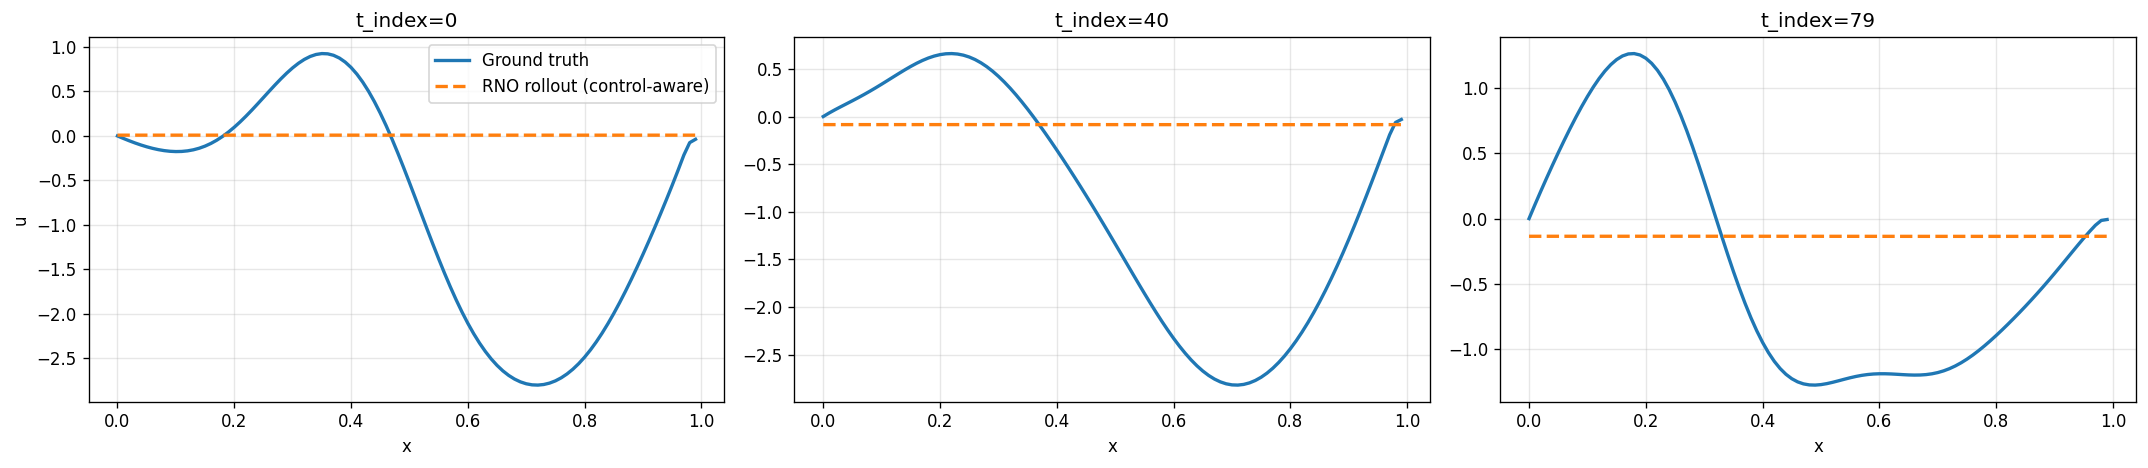

In [37]:
# 11) Single-Trajectory Native Rollout Test (with controls)
# Native rolled axis: chunk index k (trajectory window steps), not chunk-internal time.
# Control alignment rule: use ctrl_seq[:, k] with current state u_k to predict u_{k+1}.

rollout_h_native = 5
sample_id_native = 0
start_chunk_native = 0
assert rollout_h_native >= 1

traj_sol = sol_test_chunks[sample_id_native]  # (n_chunks, chunk_len, nx, 1)
traj_ctrl = ctrl_test_chunks[sample_id_native]  # (n_chunks, chunk_len, n_ctrl, 1)

if traj_sol.shape[0] != traj_ctrl.shape[0]:
    raise ValueError(
        f"State/control chunk count mismatch: sol={traj_sol.shape[0]}, ctrl={traj_ctrl.shape[0]}"
    )

max_start = traj_sol.shape[0] - n_intervals - rollout_h_native
if max_start < 0:
    raise ValueError(
        f"Not enough chunks for rollout_h={rollout_h_native}. Have n_chunks={traj_sol.shape[0]}, n_intervals={n_intervals}."
    )

start = min(start_chunk_native, max_start)
chunk_len = int(traj_sol.shape[1])
nx_local = int(traj_sol.shape[2])
n_ctrl_local = int(traj_ctrl.shape[2])

# Initial condition is the last state in the history window [start, ..., start+n_intervals-1].
u0_chunk = traj_sol[start + n_intervals - 1]  # (chunk_len, nx, 1)
u0 = u0_chunk.permute(2, 0, 1).unsqueeze(0).to(device).float()  # (1, 1, chunk_len, nx)

# Controls are exogenous and aligned with current rollout state u_k.
ctrl_seq_chunks = traj_ctrl[
    start + n_intervals - 1 : start + n_intervals - 1 + rollout_h_native
]  # (rollout_h, chunk_len, n_ctrl, 1)
ctrl_seq = (
    ctrl_seq_chunks.permute(0, 3, 1, 2).unsqueeze(0).to(device).float()
)  # (1, rollout_h, 1, chunk_len, n_ctrl)

# Ground-truth next chunks to compare against predicted rollout chunks.
y_true_chunks = traj_sol[
    start + n_intervals : start + n_intervals + rollout_h_native
]  # (rollout_h, chunk_len, nx, 1)

print("variant:", "gaussian_actuators")
print("traj_sol:", tuple(traj_sol.shape))
print("traj_ctrl:", tuple(traj_ctrl.shape))
print("u0:", tuple(u0.shape))
print("ctrl_seq:", tuple(ctrl_seq.shape))
print("y_true_chunks:", tuple(y_true_chunks.shape))

model.eval()
ar_model.eval()
with torch.no_grad():
    pred_roll = ar_model.rollout(
        u0=u0,
        ctrl_seq=ctrl_seq,
        steps=rollout_h_native,
    )  # (1, rollout_h+1, 1, chunk_len, nx)

if not torch.isfinite(pred_roll).all():
    raise ValueError("Non-finite values encountered in native control-aware rollout.")

pred_chunks = (
    pred_roll[0, 1:].permute(0, 2, 3, 1).detach().cpu()
)  # (rollout_h, chunk_len, nx, 1)
true_chunks = y_true_chunks.detach().cpu()  # (rollout_h, chunk_len, nx, 1)

assert pred_chunks.shape == true_chunks.shape, (
    pred_chunks.shape,
    true_chunks.shape,
)

pred_flat = pred_chunks.squeeze(-1).reshape(rollout_h_native * chunk_len, nx_local)
true_flat = true_chunks.squeeze(-1).reshape(rollout_h_native * chunk_len, nx_local)

mse_roll = torch.mean((pred_flat - true_flat) ** 2).item()
rel_l2_roll = (
    torch.linalg.norm(pred_flat - true_flat) / (torch.linalg.norm(true_flat) + 1e-12)
).item()

print(f"pred_roll shape: {tuple(pred_roll.shape)}")
print(f"pred_chunks shape: {tuple(pred_chunks.shape)}")
print(f"true_chunks shape: {tuple(true_chunks.shape)}")
print(f"Rollout MSE (h={rollout_h_native}): {mse_roll:.4e}")
print(f"Rollout relative L2 (h={rollout_h_native}): {rel_l2_roll:.4e}")

x_axis = x_cord.squeeze().cpu().numpy()
ids = [0, max(0, (rollout_h_native * chunk_len) // 2), rollout_h_native * chunk_len - 1]
fig, axes = plt.subplots(1, 3, figsize=(18, 4), dpi=120)
for ax, tid in zip(axes, ids):
    ax.plot(
        x_axis,
        true_flat[tid].numpy(),
        label="Ground truth",
        color="#1f77b4",
        linewidth=2,
    )
    ax.plot(
        x_axis,
        pred_flat[tid].numpy(),
        label="RNO rollout (control-aware)",
        color="#ff7f0e",
        linestyle="--",
        linewidth=2,
    )
    ax.set_title(f"t_index={tid}")
    ax.set_xlabel("x")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("u")
axes[0].legend(loc="best")
plt.tight_layout()
plt.show()


## 12) Multi-step fine-tuning helpers (control-aware)
Control-aware multi-horizon endpoint fine-tuning helper routines, mirroring `train_RNO_state_only.ipynb` behavior.


In [ ]:
# 12) Multi-step fine-tuning helpers (control-aware)
# Mirrors train_RNO_state_only.run_multistep_finetuning semantics:
# - mixed horizons h=1..fine_tuning_num_steps
# - endpoint-only loss at each horizon h
# - deterministic horizon-specific loaders
# - scheduler stepped every optimization step

fine_tuning_num_steps = 5
fine_tune_ep = 25
fine_tuning_lr = 1e-3
fine_tune_scheduler_step = 2000
fine_tune_scheduler_gamma = 0.5
horizons = list(range(1, fine_tuning_num_steps + 1))


def build_state_control_windows_horizon(
    sol_chunks, ctrl_chunks, n_intervals_inner, horizon_inner
):
    # sol_chunks:  (n_traj, n_chunks, T, nx, 1)
    # ctrl_chunks: (n_traj, n_chunks, T, n_ctrl, 1)
    x_state_list, x_ctrl_hist_list, ctrl_seq_list, y_list = [], [], [], []

    n_chunks = sol_chunks.shape[1]
    max_i = n_chunks - n_intervals_inner - horizon_inner

    for traj_sol, traj_ctrl in zip(sol_chunks, ctrl_chunks):
        for i in range(max_i):
            # History windows
            x_state_hist = traj_sol[i : i + n_intervals_inner]  # (T_hist, T, nx, 1)
            x_ctrl_hist = traj_ctrl[i : i + n_intervals_inner]  # (T_hist, T, n_ctrl, 1)

            # Control alignment convention: ctrl_k is paired with u_k.
            # u0 is the last state in history at index i+T_hist-1, so first control
            # for rollout is also index i+T_hist-1.
            ctrl_seq_h = traj_ctrl[
                i + n_intervals_inner - 1 : i + n_intervals_inner - 1 + horizon_inner
            ]  # (h, T, n_ctrl, 1)

            # Endpoint target at horizon h (same as state-only routine semantics)
            y_endpoint = traj_sol[
                i + n_intervals_inner + horizon_inner - 1
            ]  # (T, nx, 1)

            x_state_list.append(x_state_hist)
            x_ctrl_hist_list.append(x_ctrl_hist)
            ctrl_seq_list.append(ctrl_seq_h)
            y_list.append(y_endpoint)

    T_local = int(sol_chunks.shape[2])
    nx_local = int(sol_chunks.shape[3])
    n_ctrl_local = int(ctrl_chunks.shape[3])

    if len(x_state_list) == 0:
        x_state_empty = torch.empty(0, n_intervals_inner, 1, T_local, nx_local)
        x_ctrl_hist_empty = torch.empty(0, n_intervals_inner, 1, T_local, n_ctrl_local)
        ctrl_seq_empty = torch.empty(0, horizon_inner, 1, T_local, n_ctrl_local)
        y_empty = torch.empty(0, 1, T_local, nx_local)
        return (
            x_state_empty.float(),
            x_ctrl_hist_empty.float(),
            ctrl_seq_empty.float(),
            y_empty.float(),
        )

    x_state = torch.stack(x_state_list, dim=0).float()  # (N, T_hist, T, nx, 1)
    x_ctrl_hist = torch.stack(
        x_ctrl_hist_list, dim=0
    ).float()  # (N, T_hist, T, n_ctrl, 1)
    ctrl_seq = torch.stack(ctrl_seq_list, dim=0).float()  # (N, h, T, n_ctrl, 1)
    y_endpoint = torch.stack(y_list, dim=0).float()  # (N, T, nx, 1)

    x_state = x_state.permute(0, 1, 4, 2, 3).contiguous()  # (N, T_hist, 1, T, nx)
    x_ctrl_hist = x_ctrl_hist.permute(
        0, 1, 4, 2, 3
    ).contiguous()  # (N, T_hist, 1, T, n_ctrl)
    ctrl_seq = ctrl_seq.permute(0, 1, 4, 2, 3).contiguous()  # (N, h, 1, T, n_ctrl)
    y_endpoint = y_endpoint.permute(0, 3, 1, 2).contiguous()  # (N, 1, T, nx)

    return x_state, x_ctrl_hist, ctrl_seq, y_endpoint


multi_step_train_data = {}
multi_step_test_data = {}
for h in horizons:
    x_state_tr, x_ctrl_hist_tr, ctrl_seq_tr, y_tr = build_state_control_windows_horizon(
        sol_train_chunks,
        ctrl_train_chunks,
        n_intervals,
        h,
    )
    x_state_te, x_ctrl_hist_te, ctrl_seq_te, y_te = build_state_control_windows_horizon(
        sol_test_chunks,
        ctrl_test_chunks,
        n_intervals,
        h,
    )
    multi_step_train_data[h] = (x_state_tr, x_ctrl_hist_tr, ctrl_seq_tr, y_tr)
    multi_step_test_data[h] = (x_state_te, x_ctrl_hist_te, ctrl_seq_te, y_te)

n_eval_per_horizon = {h: multi_step_test_data[h][0].shape[0] for h in horizons}
print("Multi-step evaluation samples per horizon:", n_eval_per_horizon)


def run_multistep_finetuning(
    model_obj,
    ar_model_obj,
    train_data_by_h,
    test_data_by_h,
    ft_seed,
    n_epochs=None,
    steps_per_epoch=None,
):
    if n_epochs is None:
        n_epochs = fine_tune_ep

    # Build deterministic train loaders per horizon.
    train_loaders = {}
    test_loaders = {}
    for h in horizons:
        xh_state_tr, xh_ctrl_hist_tr, xh_ctrl_seq_tr, yh_tr = train_data_by_h[h]
        xh_state_te, xh_ctrl_hist_te, xh_ctrl_seq_te, yh_te = test_data_by_h[h]

        g_h = torch.Generator(device="cpu")
        g_h.manual_seed(ft_seed)

        train_loaders[h] = DataLoader(
            torch.utils.data.TensorDataset(
                xh_state_tr, xh_ctrl_hist_tr, xh_ctrl_seq_tr, yh_tr
            ),
            batch_size=batch_size,
            shuffle=True,
            drop_last=True,
            generator=g_h,
        )
        test_loaders[h] = DataLoader(
            torch.utils.data.TensorDataset(
                xh_state_te, xh_ctrl_hist_te, xh_ctrl_seq_te, yh_te
            ),
            batch_size=batch_size,
            shuffle=False,
            drop_last=False,
        )

    # KS-style mixed horizon list: one entry per batch in each horizon loader.
    multi_step_list_template = []
    for h in horizons:
        multi_step_list_template += [h for _ in range(len(train_loaders[h]))]

    optimizer_ft = torch.optim.Adam(
        model_obj.parameters(), lr=fine_tuning_lr, weight_decay=weight_decay
    )
    scheduler_ft = torch.optim.lr_scheduler.StepLR(
        optimizer_ft,
        step_size=fine_tune_scheduler_step,
        gamma=fine_tune_scheduler_gamma,
    )

    ft_logs = {
        "train_rel_l2": {h: [] for h in horizons},
        "test_rel_l2": {h: [] for h in horizons},
    }

    print("Begin multi-step fine-tuning:")
    rng_ft = random.Random(ft_seed)
    debug_shapes_printed = False

    for ep in range(1, n_epochs + 1):
        t_start = time.time()

        multi_step_list = multi_step_list_template.copy()
        rng_ft.shuffle(multi_step_list)
        if steps_per_epoch is not None:
            steps_per_epoch = int(steps_per_epoch)
            multi_step_list = multi_step_list[
                : max(0, min(steps_per_epoch, len(multi_step_list)))
            ]

        iters = {h: iter(train_loaders[h]) for h in horizons}

        model_obj.train()
        ar_model_obj.train()
        train_l2_sum = {h: 0.0 for h in horizons}
        train_count = {h: 0 for h in horizons}

        for h in tqdm(multi_step_list, total=len(multi_step_list)):
            xb_state, xb_ctrl_hist, xb_ctrl_seq, yb = next(iters[h])
            xb_state = xb_state.to(device).float()  # (B, T_hist, 1, T, nx)
            xb_ctrl_hist = xb_ctrl_hist.to(device).float()  # (B, T_hist, 1, T, n_ctrl)
            xb_ctrl_seq = xb_ctrl_seq.to(device).float()  # (B, h, 1, T, n_ctrl)
            yb = yb.to(device).float()  # (B, 1, T, nx)

            if xb_state.ndim != 5 or xb_state.shape[2] != 1:
                raise ValueError(
                    f"Expected xb_state (B,T_hist,1,T,nx), got {tuple(xb_state.shape)}"
                )
            if xb_ctrl_hist.ndim != 5 or xb_ctrl_hist.shape[2] != 1:
                raise ValueError(
                    f"Expected xb_ctrl_hist (B,T_hist,1,T,n_ctrl), got {tuple(xb_ctrl_hist.shape)}"
                )
            if (
                xb_ctrl_seq.ndim != 5
                or xb_ctrl_seq.shape[1] != h
                or xb_ctrl_seq.shape[2] != 1
            ):
                raise ValueError(
                    f"Expected xb_ctrl_seq (B,{h},1,T,n_ctrl), got {tuple(xb_ctrl_seq.shape)}"
                )
            if yb.ndim != 4 or yb.shape[1] != 1:
                raise ValueError(f"Expected yb (B,1,T,nx), got {tuple(yb.shape)}")

            # Initial state for rollout is the last state in history.
            u0 = xb_state[:, -1]  # (B, 1, T, nx)
            pred_rollout = ar_model_obj.rollout(u0=u0, ctrl_seq=xb_ctrl_seq, steps=h)
            out_window = pred_rollout[:, -1]  # (B, 1, T, nx)

            if not debug_shapes_printed:
                print("xb_state shape:", tuple(xb_state.shape))
                print("xb_ctrl_hist shape:", tuple(xb_ctrl_hist.shape))
                print("xb_ctrl_seq shape:", tuple(xb_ctrl_seq.shape))
                print("pred_rollout shape:", tuple(pred_rollout.shape))
                print("pred_rollout[:, -1] shape:", tuple(pred_rollout[:, -1].shape))
                print("yb shape:", tuple(yb.shape))
                debug_shapes_printed = True

            l2 = lploss(out_window, yb)

            optimizer_ft.zero_grad()
            l2.backward()
            optimizer_ft.step()
            scheduler_ft.step()

            train_l2_sum[h] += l2.item()
            train_count[h] += xb_state.size(0)

        model_obj.eval()
        ar_model_obj.eval()
        test_rel_sum = {h: 0.0 for h in horizons}
        test_count = {h: 0 for h in horizons}

        with torch.no_grad():
            for h in horizons:
                for xb_state, xb_ctrl_hist, xb_ctrl_seq, yb in test_loaders[h]:
                    xb_state = xb_state.to(device).float()
                    xb_ctrl_hist = xb_ctrl_hist.to(device).float()
                    xb_ctrl_seq = xb_ctrl_seq.to(device).float()
                    yb = yb.to(device).float()

                    u0 = xb_state[:, -1]  # (B, 1, T, nx)
                    pred_rollout = ar_model_obj.rollout(
                        u0=u0, ctrl_seq=xb_ctrl_seq, steps=h
                    )
                    out_window = pred_rollout[:, -1]  # (B, 1, T, nx)

                    test_rel_sum[h] += lploss(out_window, yb).item()
                    test_count[h] += xb_state.size(0)

        train_l2_list = []
        test_l2_list = []
        for h in horizons:
            train_l2_h = train_l2_sum[h] / max(train_count[h], 1)
            test_l2_h = test_rel_sum[h] / max(test_count[h], 1)

            ft_logs["train_rel_l2"][h].append(train_l2_h)
            ft_logs["test_rel_l2"][h].append(test_l2_h)

            train_l2_list.append(train_l2_h)
            test_l2_list.append(test_l2_h)

        runtime = time.time() - t_start
        print(
            f"Fine-tune epoch: {ep} Time: {runtime:.2f} Train L2: {train_l2_list} Test L2: {test_l2_list}"
        )

    return ft_logs


Multi-step evaluation samples per horizon: {1: 380, 2: 360, 3: 340, 4: 320, 5: 300}


## 13) Multi-step fine-tuning sanity
Runs one minimal fine-tuning update (`n_epochs=1`, `steps_per_epoch=1`) on a copied model/wrapper and checks endpoint-shape + finiteness.


In [39]:
# 13) Multi-step fine-tuning sanity (1 epoch, 1 step)
import copy

h_smoke = min(2, fine_tuning_num_steps)
xh_state, xh_ctrl_hist, xh_ctrl_seq, yh = multi_step_train_data[h_smoke]

if xh_state.shape[0] == 0:
    raise ValueError(f"No multi-step samples available for h={h_smoke}")

assert xh_state.shape[1:] == (n_intervals, 1, T, xh_state.shape[-1]), xh_state.shape
assert xh_ctrl_hist.shape[1] == n_intervals, xh_ctrl_hist.shape
assert xh_ctrl_seq.shape[1] == h_smoke, xh_ctrl_seq.shape
assert yh.shape[1:] == (1, T, yh.shape[-1]), yh.shape

model_smoke = copy.deepcopy(model).to(device)
ar_model_smoke = RNOControlARGaussianActuators(
    rno=model_smoke,
    mus=GAUSS_MUS,
    sigma=GAUSS_SIGMA,
    x_min=GAUSS_X_MIN,
    x_max=GAUSS_X_MAX,
    normalize=GAUSS_NORMALIZE,
).to(device)

ft_logs_smoke = run_multistep_finetuning(
    model_obj=model_smoke,
    ar_model_obj=ar_model_smoke,
    train_data_by_h=multi_step_train_data,
    test_data_by_h=multi_step_test_data,
    ft_seed=seed,
    n_epochs=1,
    steps_per_epoch=1,
)

B_smoke = min(2, xh_state.shape[0])
xb_state = xh_state[:B_smoke].to(device).float()  # (B, T_hist, 1, T, nx)
xb_ctrl_seq = xh_ctrl_seq[:B_smoke].to(device).float()  # (B, h, 1, T, n_ctrl)
yb = yh[:B_smoke].to(device).float()  # (B, 1, T, nx)

with torch.no_grad():
    pred_roll_smoke = ar_model_smoke.rollout(
        u0=xb_state[:, -1],
        ctrl_seq=xb_ctrl_seq,
        steps=h_smoke,
    )  # (B, h+1, 1, T, nx)

pred_endpoint = pred_roll_smoke[:, -1]  # (B, 1, T, nx)
assert pred_endpoint.shape == yb.shape, (pred_endpoint.shape, yb.shape)
assert torch.isfinite(pred_roll_smoke).all(), "Non-finite values in smoke rollout"

print("Smoke fine-tune logs keys:", ft_logs_smoke.keys())
print("Smoke pred_rollout shape:", tuple(pred_roll_smoke.shape))
print("Smoke endpoint shape:", tuple(pred_endpoint.shape), "target:", tuple(yb.shape))
print("Multi-step fine-tuning sanity passed.")


Begin multi-step fine-tuning:


  0%|          | 0/1 [00:00<?, ?it/s]

xb_state shape: (75, 5, 1, 16, 100)
xb_ctrl_hist shape: (75, 5, 1, 16, 4)
xb_ctrl_seq shape: (75, 3, 1, 16, 4)
pred_rollout shape: (75, 4, 1, 16, 100)
pred_rollout[:, -1] shape: (75, 1, 16, 100)
yb shape: (75, 1, 16, 100)
Fine-tune epoch: 1 Time: 1.60 Train L2: [0.0, 0.0, 0.9952256266276042, 0.0, 0.0] Test L2: [0.9992913070477938, 0.9959951294793024, 0.9967669767491958, 0.9983879625797272, 0.9999101257324219]
Smoke fine-tune logs keys: dict_keys(['train_rel_l2', 'test_rel_l2'])
Smoke pred_rollout shape: (2, 3, 1, 16, 100)
Smoke endpoint shape: (2, 1, 16, 100) target: (2, 1, 16, 100)
Multi-step fine-tuning sanity passed.


## 14) Multi-step fine-tuning training run
Runs the full control-aware multi-step fine-tuning loop over horizons 1..5 for 25 epochs.


In [40]:
# 14) Multi-step fine-tuning training run
# Uses the same hyperparameters as defined in section #12.

fine_tuning_num_steps = 5
fine_tune_ep = 25
fine_tuning_lr = 1e-3
fine_tune_scheduler_step = 2000
fine_tune_scheduler_gamma = 0.5
horizons = list(range(1, fine_tuning_num_steps + 1))

# Ensure horizon data dictionaries are aligned with configured horizons.
for h in horizons:
    if h not in multi_step_train_data or h not in multi_step_test_data:
        raise ValueError(f"Missing multi-step dataset for horizon h={h}")

multistep_finetune_logs = run_multistep_finetuning(
    model_obj=model,
    ar_model_obj=ar_model,
    train_data_by_h=multi_step_train_data,
    test_data_by_h=multi_step_test_data,
    ft_seed=seed,
    n_epochs=fine_tune_ep,
)

print("Completed multi-step fine-tuning.")
print("Logged horizons:", list(multistep_finetune_logs["train_rel_l2"].keys()))
print(
    "Final train L2 per horizon:",
    [multistep_finetune_logs["train_rel_l2"][h][-1] for h in horizons],
)
print(
    "Final test L2 per horizon:",
    [multistep_finetune_logs["test_rel_l2"][h][-1] for h in horizons],
)


Begin multi-step fine-tuning:


  0%|          | 0/90 [00:00<?, ?it/s]

xb_state shape: (75, 5, 1, 16, 100)
xb_ctrl_hist shape: (75, 5, 1, 16, 4)
xb_ctrl_seq shape: (75, 3, 1, 16, 4)
pred_rollout shape: (75, 4, 1, 16, 100)
pred_rollout[:, -1] shape: (75, 1, 16, 100)
yb shape: (75, 1, 16, 100)
Fine-tune epoch: 1 Time: 12.89 Train L2: [0.9554672241210938, 0.86277139496385, 0.7706423413311994, 0.7017418865129059, 1.0136029402414957] Test L2: [0.8664740662825735, 0.565749708811442, 0.43109440523035386, 1.0088832020759582, 2.11936762491862]


  0%|          | 0/90 [00:00<?, ?it/s]

Fine-tune epoch: 2 Time: 13.18 Train L2: [0.8265186182657878, 0.5567521520246539, 0.4257499920880353, 0.521734717873966, 0.7963520685831705] Test L2: [0.6823670939395302, 0.448774618572659, 0.41026601791381834, 0.5311705827713012, 0.7352265803019206]


...

Fine-tune epoch: 23 Time: 13.02 Train L2: [0.04220804246266683, 0.04000277761827435, 0.04567170937856038, 0.060922828375124465, 0.07846132795015971] Test L2: [0.04040269530133197, 0.033842080500390795, 0.044809727107777315, 0.05020791962742806, 0.06164219220479329]


  0%|          | 0/90 [00:00<?, ?it/s]

Fine-tune epoch: 24 Time: 13.94 Train L2: [0.03227525504430135, 0.029850036888791804, 0.034031878577338324, 0.039418943629545324, 0.04667947212855021] Test L2: [0.06291784228462922, 0.050569620397355824, 0.05084442180745742, 0.05293780602514744, 0.06137573401133219]


  0%|          | 0/90 [00:00<?, ?it/s]

Fine-tune epoch: 25 Time: 14.08 Train L2: [0.03315424108505249, 0.03139071907913476, 0.033764305114746096, 0.04711360557406556, 0.05235356152057648] Test L2: [0.034857277650582164, 0.04121312697728475, 0.047427981040057014, 0.06037514060735703, 0.07408488512039185]
Completed multi-step fine-tuning.
Logged horizons: [1, 2, 3, 4, 5]
Final train L2 per horizon: [0.03315424108505249, 0.03139071907913476, 0.033764305114746096, 0.04711360557406556, 0.05235356152057648]
Final test L2 per horizon: [0.034857277650582164, 0.04121312697728475, 0.047427981040057014, 0.06037514060735703, 0.07408488512039185]
